In [ ]:
import utils
import const
import models

import re
import pandas as pd
import torch
from itertools import combinations
from transformers import AutoTokenizer
import networkx as nx
from sklearn.metrics import confusion_matrix
from importlib import reload

In [2]:
test_doc_id = 'CNN_20130322_314'

In [3]:
doc_df = utils.get_docs([test_doc_id])

In [4]:
doc_df.iloc[0]['text']

"President Barack Obama [E1]arrived[/E1] in refugee-flooded Jordan on [TIMEX3]Friday[/TIMEX3] after [E2]scoring[/E2] a diplomatic [E3]coup[/E3] just before [E4]leaving[/E4] Israel when Prime Minister Benjamin Netanyahu [E5]apologized[/E5] to Turkey for a [TIMEX3]2010[/TIMEX3] commando [E6]raid[/E6] that [E7]killed[/E7] nine activists on a Turkish vessel in a Gaza-bound flotilla.\n\nThe apology, long [E8]sought[/E8] by Turkish Prime Minister Recep Erdogan, [E9]eased[/E9] strained feelings between Turkey and Israel, two vital U.S. allies in the Middle East.\n\nIt [E10]happened[/E10] in a phone [E29]call[/E29] to Erdogan during a final [E11]meeting[/E11] between Obama and Netanyahu at Ben Gurion International Airport in Tel Aviv [TIMEX3]minutes[/TIMEX3] before Air Force One [E12]departed[/E12] for Jordan to [E13]complete[/E13] the president's Middle East [E30]swing[/E30]. It is the first foreign [E14]trip[/E14] of his [TIMEX3]second term[/TIMEX3].\n\nA statement from Netanyahu's office [E

In [5]:
rows = []
pattern = re.compile(r"\[E(\d+)\](.*?)\[/E\1\]")

for docid, row in doc_df.iterrows():
    text = row.get("text", "")
    events = [(f"E{eiid}", verb.strip()) for eiid, verb in pattern.findall(text)]
    
    for (eiid1, verb1), (eiid2, verb2) in combinations(events, 2):
        rows.append(
            {
                "docid": docid,
                "verb1": verb1,
                "verb2": verb2,
                "eiid1": eiid1,
                "eiid2": eiid2,
            }
        )

event_pairs_df = pd.DataFrame(rows, columns=["docid", "verb1", "verb2", "eiid1", "eiid2"])
event_pairs_df.shape

(528, 5)

In [6]:
relations_df = utils.create_context_windows(event_pairs_df, doc_df)
relations_df.head()

,docid,verb1,verb2,eiid1,eiid2,context_window
0,CNN_20130322_314,arrived,scoring,E1,E2,President Barack Obama [T1]arrived[/T1] in ref...
1,CNN_20130322_314,arrived,coup,E1,E3,President Barack Obama [T1]arrived[/T1] in ref...
2,CNN_20130322_314,arrived,leaving,E1,E4,President Barack Obama [T1]arrived[/T1] in ref...
3,CNN_20130322_314,arrived,apologized,E1,E5,President Barack Obama [T1]arrived[/T1] in ref...
4,CNN_20130322_314,arrived,raid,E1,E6,President Barack Obama [T1]arrived[/T1] in ref...


In [7]:
state_dict = torch.load('./temp_rel_roberta.pt')
tokenizer = models.create_temp_rel_tokenizer()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
loader = utils.create_evaluation_loader(relations_df, tokenizer, batch_size=16)

input_ids shape: torch.Size([528, 276])
attention_mask shape: torch.Size([528, 276])


In [10]:
from transformers import AutoModelForSequenceClassification

all_preds, all_logits = [], []

num_labels = len(const.relation2id)
model = models.TemporalRelationsModel(num_labels=num_labels, tokenizer=tokenizer)
model.load_state_dict(state_dict, strict=False)
model = model.to(device)
model.eval()

with torch.no_grad():
    for input_ids, attention_mask in loader:
        input_ids = input_ids.to(device)
        attention_mask = attention_mask.to(device)

        # Keep only samples that contain both target markers
        has_t1 = (input_ids == model.t1_id).any(dim=1)
        has_t2 = (input_ids == model.t2_id).any(dim=1)
        valid = has_t1 & has_t2
        if not valid.any():
            continue

        input_ids = input_ids[valid]
        attention_mask = attention_mask[valid]

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits if hasattr(outputs, "logits") else outputs
        preds = torch.argmax(logits, dim=-1).cpu()
        logits = torch.softmax(logits, dim=-1).cpu()

        all_preds.append(preds)
        all_logits.append(logits)

y_pred = torch.cat(all_preds).numpy() if all_preds else torch.empty(0, dtype=torch.long).numpy()
y_logits = torch.cat(all_logits).numpy() if all_logits else torch.empty(0, dtype=torch.long).numpy()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To dis

In [11]:
relations_df["predicted_relation"] = [const.id2relation[p] for p in y_pred]
relations_df[["pred_vague", "pred_before", "pred_after", "pred_equal"]] = [pred for pred in y_logits]
relations_df["confidence"] = relations_df[["pred_vague", "pred_before", "pred_after", "pred_equal"]].max(axis=1)

In [12]:
relations_df.head(10)

,docid,verb1,verb2,eiid1,eiid2,context_window,predicted_relation,pred_vague,pred_before,pred_after,pred_equal,confidence
0,CNN_20130322_314,arrived,scoring,E1,E2,President Barack Obama [T1]arrived[/T1] in ref...,AFTER,0.000103,1.162570e-06,9.998530e-01,0.000043,0.999853
1,CNN_20130322_314,arrived,coup,E1,E3,President Barack Obama [T1]arrived[/T1] in ref...,AFTER,0.047096,7.666631e-04,9.479733e-01,0.004164,0.947973
2,CNN_20130322_314,arrived,leaving,E1,E4,President Barack Obama [T1]arrived[/T1] in ref...,BEFORE,0.302008,6.249439e-01,2.188297e-03,0.070860,0.624944
3,CNN_20130322_314,arrived,apologized,E1,E5,President Barack Obama [T1]arrived[/T1] in ref...,AFTER,0.213456,2.327913e-01,3.293550e-01,0.224398,0.329355
4,CNN_20130322_314,arrived,raid,E1,E6,President Barack Obama [T1]arrived[/T1] in ref...,AFTER,0.000078,7.711071e-08,9.999155e-01,0.000007,0.999915
5,CNN_20130322_314,arrived,killed,E1,E7,President Barack Obama [T1]arrived[/T1] in ref...,AFTER,0.000051,2.499079e-08,9.999431e-01,0.000006,0.999943
6,CNN_20130322_314,arrived,sought,E1,E8,President Barack Obama [T1]arrived[/T1] in ref...,VAGUE,0.940022,7.111800e-04,5.725924e-02,0.002008,0.940022
7,CNN_20130322_314,arrived,eased,E1,E9,President Barack Obama [T1]arrived[/T1] in ref...,VAGUE,0.767827,2.136769e-01,2.337290e-03,0.016158,0.767827
8,CNN_20130322_314,arrived,happened,E1,E10,President Barack Obama [T1]arrived[/T1] in ref...,BEFORE,0.036245,9.637117e-01,7.426666e-07,0.000042,0.963712
9,CNN_20130322_314,arrived,call,E1,E29,President Barack Obama [T1]arrived[/T1] in ref...,VAGUE,0.792057,2.077394e-01,4.770067e-05,0.000156,0.792057


# Create graph

In [13]:
def create_node_label(row, eiid_col, verb_col):
    return f"{row[eiid_col]}\n{row[verb_col]}"

In [14]:
THR_CONFIDENCE = 0.5

G = nx.DiGraph()

nodes = set(relations_df.apply(lambda row: create_node_label(row, 'eiid1', 'verb1'), axis=1)).union(
    set(relations_df.apply(lambda row: create_node_label(row, 'eiid2', 'verb2'), axis=1))
)

G.add_nodes_from(nodes)

for _, row in relations_df.iterrows():
    verb1 = create_node_label(row, 'eiid1', 'verb1')
    verb2 = create_node_label(row, 'eiid2', 'verb2')
    relation = row['predicted_relation']
    
    if row['confidence'] < THR_CONFIDENCE:
        continue

    if relation == 'BEFORE':
        G.add_edge(verb1, verb2, confidence=row['confidence'])
    elif relation == 'AFTER':
        G.add_edge(verb2, verb1, confidence=row['confidence'])

In [15]:
def get_bidirectional_count(G):
    count = 0
    for u, v in G.edges():
        if G.has_edge(v, u):
            count += 1
    return count

In [16]:
def remove_bidirectional_edges(G):
    to_remove = set()
    seen_pairs = set()

    for u, v in G.edges():
        pair = tuple(sorted((u, v)))
        if pair in seen_pairs:
            continue
        seen_pairs.add(pair)

        if G.has_edge(v, u):
            c_uv = G.get_edge_data(u, v).get("confidence", 0.0)
            c_vu = G.get_edge_data(v, u).get("confidence", 0.0)

            if c_uv > c_vu:
                to_remove.add((v, u))
            elif c_vu > c_uv:
                to_remove.add((u, v))
            else:
                # tie: keep one direction deterministically
                to_remove.add((v, u))
                
    G.remove_edges_from(to_remove)
    print(f"Removed {len(to_remove)} bidirectional edges.")
    return G, len(to_remove)

def add_transitive_edges(G):
    transitive_added = 0
    for u, v in list(G.edges()):
        for w in G.successors(v):
            if not G.has_edge(u, w):
                G.add_edge(u, w, confidence=min(G.get_edge_data(u, v)['confidence'], G.get_edge_data(v, w)['confidence']))
                transitive_added += 1
    print(f"Added {transitive_added} transitive edges.")
    return G, transitive_added

In [17]:
max_iter = 100
history = []

for step in range(1, max_iter + 1):
    # 1) remove bidirectional edges (if any)
    bidir_before = get_bidirectional_count(G)
    n_removed = 0
    if bidir_before > 0:
        G, n_removed = remove_bidirectional_edges(G)

    # 2) add transitive edges
    G, transitive_added = add_transitive_edges(G)

    bidir_after = get_bidirectional_count(G)
    history.append(
        {
            "iter": step,
            "bidir_before": bidir_before,
            "removed": n_removed,
            "transitive_added": transitive_added,
            "bidir_after": bidir_after,
            "edges": G.number_of_edges(),
        }
    )

    # Stop when graph is stable
    if n_removed == 0 and transitive_added == 0:
        print(f"Converged at iteration {step}.")
        break
else:
    print(f"Reached max_iter={max_iter} before full convergence.")

pd.DataFrame(history)

Added 60 transitive edges.
Removed 11 bidirectional edges.
Added 5 transitive edges.
Removed 5 bidirectional edges.
Added 0 transitive edges.
Added 0 transitive edges.
Converged at iteration 4.


,iter,bidir_before,removed,transitive_added,bidir_after,edges
0,1,0,0,60,19,491
1,2,19,11,5,8,485
2,3,8,5,0,0,480
3,4,0,0,0,0,480


# Visualize graph

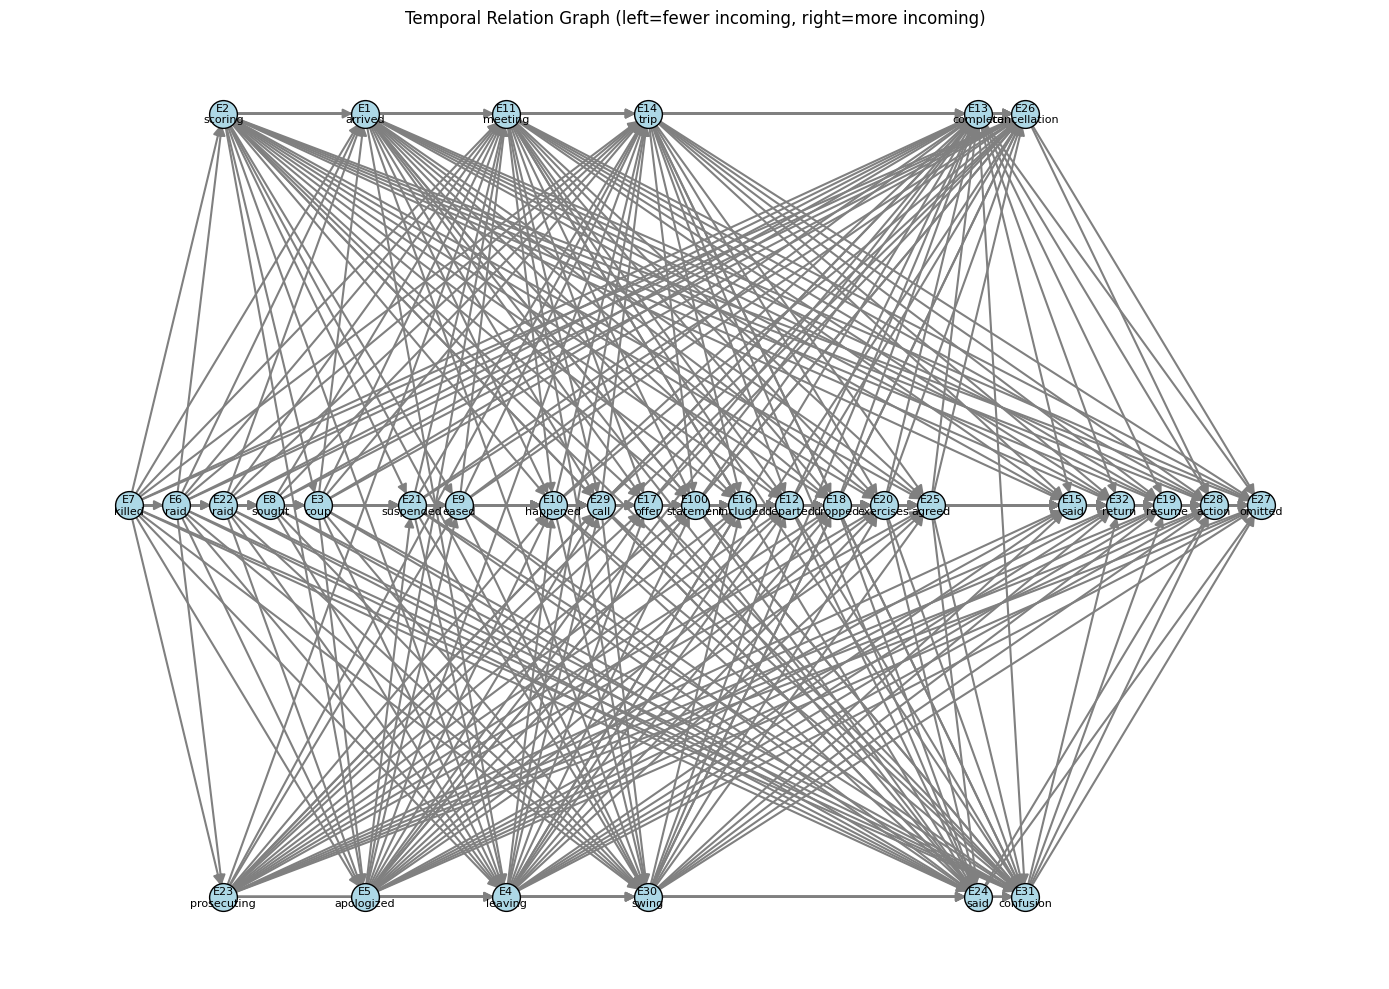

In [18]:
import matplotlib.pyplot as plt

# X-position by incoming degree: fewer incoming -> left, more incoming -> right
in_deg = dict(G.in_degree())
deg_levels = sorted(set(in_deg.values()))
x_by_deg = {d: i for i, d in enumerate(deg_levels)}

# Build positions (spread nodes vertically inside each in-degree column)
pos = {}
for d in deg_levels:
    same_deg_nodes = sorted([n for n in G.nodes() if in_deg[n] == d])
    n = len(same_deg_nodes)
    for i, node in enumerate(same_deg_nodes):
        y = 0.0 if n == 1 else 1 - (2 * i / (n - 1))  # from 1 to -1
        pos[node] = (x_by_deg[d], y)

plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(G, pos, node_size=400, node_color="lightblue", edgecolors="black")
nx.draw_networkx_edges(G, pos, arrows=True, arrowstyle="-|>", arrowsize=14, width=1.5, edge_color="gray")
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Temporal Relation Graph (left=fewer incoming, right=more incoming)")
plt.axis("off")
plt.tight_layout()
plt.show()

In [19]:
from IPython.display import display, HTML

text = doc_df.iloc[0]['text']

paragraph_html = "<p style='line-height:1.7; font-size:15px;'>" + text.replace("\n\n", "</p><p style='line-height:1.7; font-size:15px;'>") + "</p>"
display(HTML(paragraph_html))

# Testing with ground truth relations

In [20]:
all_relations = utils.get_relations()
test_relations = all_relations[all_relations['docid'] == test_doc_id]
test_relations['relation_id'] = test_relations['relation'].apply(lambda r: const.relation2id.get(r, -1))
test_relations['label1'] = test_relations.apply(lambda row: create_node_label(row, 'eiid1', 'verb1'), axis=1)
test_relations['label2'] = test_relations.apply(lambda row: create_node_label(row, 'eiid2', 'verb2'), axis=1)
test_relations.head()

,docid,verb1,verb2,eiid1,eiid2,relation,relation_id,label1,label2
780,CNN_20130322_314,arrived,scoring,E1,E2,AFTER,2,E1\narrived,E2\nscoring
781,CNN_20130322_314,arrived,leaving,E1,E4,VAGUE,0,E1\narrived,E4\nleaving
782,CNN_20130322_314,arrived,apologized,E1,E5,VAGUE,0,E1\narrived,E5\napologized
783,CNN_20130322_314,arrived,killed,E1,E7,AFTER,2,E1\narrived,E7\nkilled
784,CNN_20130322_314,scoring,leaving,E2,E4,BEFORE,1,E2\nscoring,E4\nleaving


In [21]:
test_relations = test_relations.copy()

def infer_pred_relation_id(row):
    if G.has_edge(row["label1"], row["label2"]):
        return 1
    elif G.has_edge(row["label2"], row["label1"]):
        return 2
    return 0

test_relations["pred_relation_id"] = test_relations.apply(infer_pred_relation_id, axis=1)
test_relations[["label1", "label2", "relation_id", "pred_relation_id"]].head()

,label1,label2,relation_id,pred_relation_id
780,E1\narrived,E2\nscoring,2,2
781,E1\narrived,E4\nleaving,0,1
782,E1\narrived,E5\napologized,0,0
783,E1\narrived,E7\nkilled,2,2
784,E2\nscoring,E4\nleaving,1,1


In [22]:
test_relations = test_relations[(test_relations['relation_id'] != 0) & (test_relations['relation_id'] != 3)]

In [23]:
label_ids = [0, 1, 2, 3]
cm = confusion_matrix(test_relations['relation_id'], test_relations['relation_id'], labels=label_ids)

cm_df = pd.DataFrame(
    cm,
    index=[f"true_{const.id2relation[i]}" for i in label_ids],
    columns=[f"pred_{const.id2relation[i]}" for i in label_ids],
)
display(cm_df)

,pred_VAGUE,pred_BEFORE,pred_AFTER,pred_EQUAL
true_VAGUE,0,0,0,0
true_BEFORE,0,15,0,0
true_AFTER,0,0,10,0
true_EQUAL,0,0,0,0
